# 🌹 Building Numerical Roses: 
## A Valentine’s Day Python Visualization

A Guided Exploration of Parametric Beauty with a playful journey through NumPy, Matplotlib, and mathematical beauty.

### [Sumudu Tennakoon, PhD](https://www.linkedin.com/in/sumudutennakoon)


<hr>

This notebook is designed for you to explore at your own pace. You’ll build a mathematical rose step‑by‑step, using simple functions that combine into a surprisingly rich geometric structure. Each section introduces one idea, shows how to visualize it, and invites you to experiment with the parameters to see how the shape evolves.

## What You’ll Learn
By the end of this notebook, you will:

* Build a 3D parametric surface using NumPy
* Understand how vectorized math creates complex geometry
* Design and color a procedural rose
* Compose a scene with multiple objects
* Animate a 3D visualization using Matplotlib

This tutorial blends art, math, and code—perfect for refreshing fundamentals or exploring creative visualization.

Inspired by this post on MathWorks Blog by Ned Gulley: https://blogs.mathworks.com/community/2021/02/12/happy-valentines-day

<hr>

# 1. Setup: Libraries and Parameters

Concepts introduced
* Vectorized computation
* Parameter control
* Reproducible geometry

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.animation import FuncAnimation

In [2]:
n = 400                 # Resolution of the surface
A = 2.0                 # Vertical scaling
B = 1.0                 # Shape modifier
C = 8.0                 # Petal decay rate
PETAL_NUM = 3.5         # Number of petals
STEM_RADIUS = 0.05       # Thickness of stem

# 2. Parameter Space: From Numbers to Geometry

Concepts introduced
* Parametric surfaces
* Meshgrids
* Polar → Cartesian transformation

We define two independent parameters:
* r: radial distance
* θ: angular sweep

The below code creates a 2D parameter space—every point (R, THETA) becomes a point on the rose.

In [3]:
r = np.linspace(0, 1, n)
theta = np.linspace(-2, 20*np.pi, n)
R, THETA = np.meshgrid(r, theta)

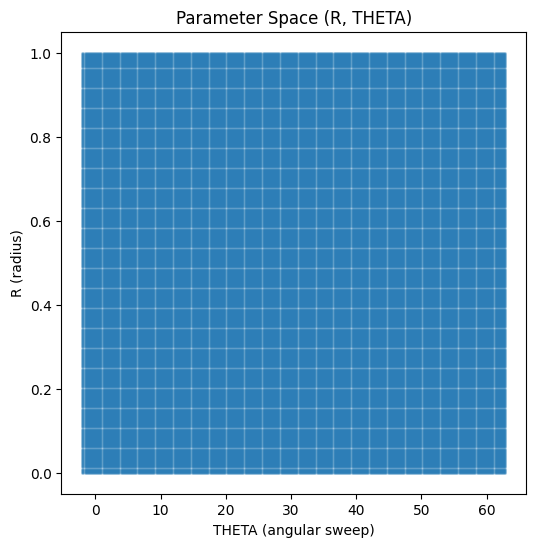

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(THETA.flatten(), R.flatten(), s=1, alpha=0.3)
plt.xlabel("THETA (angular sweep)")
plt.ylabel("R (radius)")
plt.title("Parameter Space (R, THETA)")
plt.show()


# 3. Creating the Rose Petals

Concepts introduced
* Exponential decay
* Periodic modulation
* Vectorized trigonometry

### `phi` 

Intuitive interpretation
* `phi` controls the petal curl.
* Near the center, petals are tightly wrapped.
* As the rose spirals outward, the curl decays exponentially,
* allowing the petals to open naturally.

Numerical Explanation

`phi` changes at every point of your parameter space (R, THETA).
* `(np.pi/2)` is the maximum curl.
* `np.exp(-THETA / (C * np.pi))` is the decay factor.
    * 1 → petals are tightly curled.
    * 0 → petals flatten out




In [5]:
phi = (np.pi/2) * np.exp(-THETA / (C * np.pi))

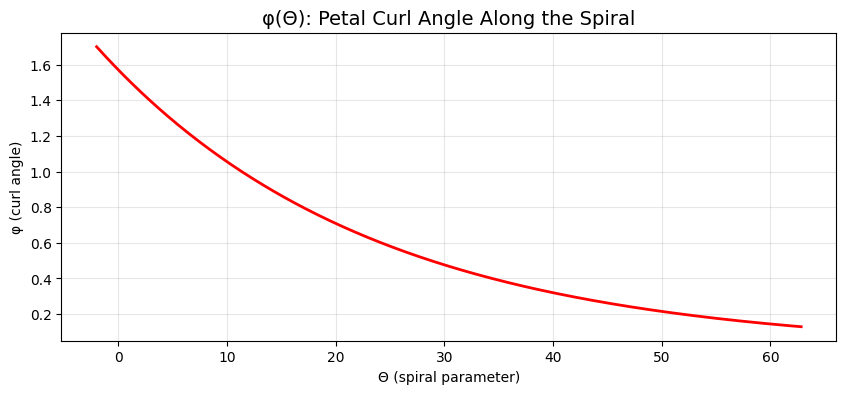

In [6]:
# Extract φ along the spiral direction (independent of R)
phi_theta = phi[:, 0]   # any column works; φ does not depend on R

plt.figure(figsize=(10, 4))
plt.plot(theta, phi_theta, color='red', linewidth=2)

plt.title("φ(Θ): Petal Curl Angle Along the Spiral", fontsize=14)
plt.xlabel("Θ (spiral parameter)")
plt.ylabel("φ (curl angle)")
plt.grid(alpha=0.3)

plt.show()


The below code controls how petals curl inward as they spiral.

In [7]:
x = 1 - (1/2) * (
    (5/4) * (1 - np.mod(PETAL_NUM * THETA, 2*np.pi) / np.pi)**2 - 1/4
)**2

This expression creates petal repetition—a numerical rhythm.

In [8]:
y = A * (R**2) * (B*R - 1)**2 * np.sin(phi)

# 4. From Math to 3D Space

Concepts introduced
* Coordinate transformation
* Surface construction

In [9]:
X_rose = x * (R*np.sin(phi) + y*np.cos(phi)) * np.sin(THETA)
Y_rose = x * (R*np.sin(phi) + y*np.cos(phi)) * np.cos(THETA)
Z_rose = x * (R*np.cos(phi) - y*np.sin(phi))

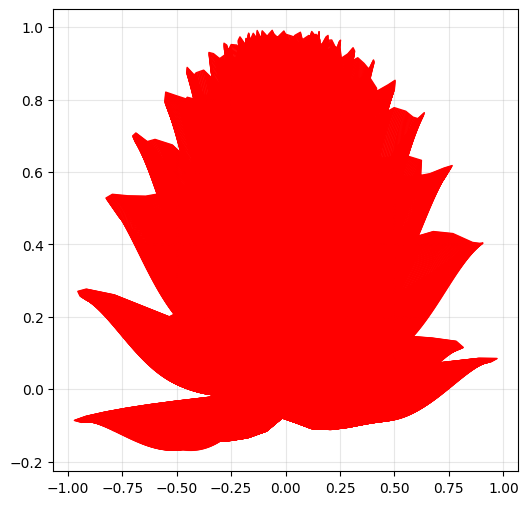

In [10]:
plt.figure(figsize=(6, 6))
plt.plot(X_rose, Z_rose, color='red', linewidth=1)
plt.grid(alpha=0.3)
plt.show()

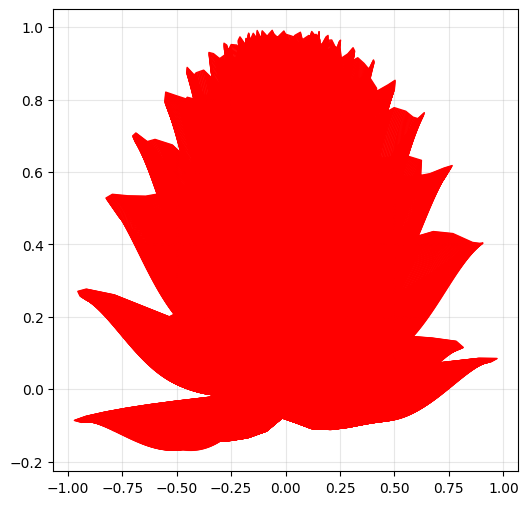

In [11]:
plt.figure(figsize=(6, 6))
plt.plot(X_rose, Z_rose, color='red', linewidth=1)
plt.grid(alpha=0.3)
plt.show()

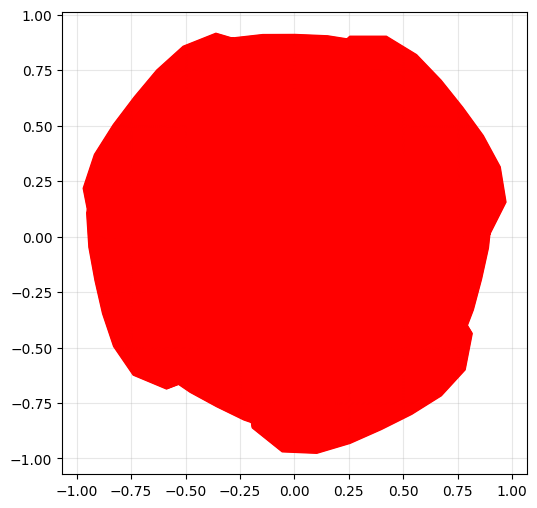

In [12]:
plt.figure(figsize=(6, 6))
plt.plot(X_rose, Y_rose, color='red', linewidth=1)
plt.grid(alpha=0.3)

plt.show()

At this point, we’ve mathematically grown a rose 🌹.

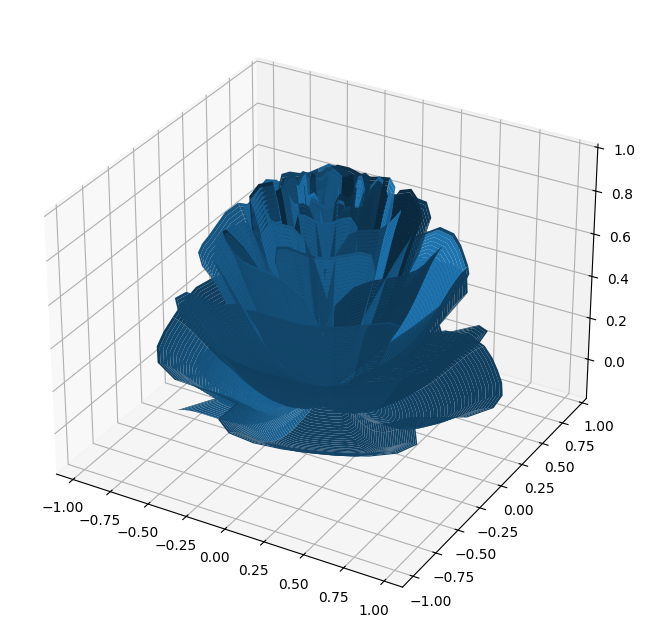

In [13]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_rose, Y_rose, Z_rose, antialiased=True, linewidth=0)

plt.show()

# 5. Adding the Stem

Concepts introduced
* Cylindrical geometry
* Mesh reuse

In [14]:
r_stem = np.linspace(-2, 0, 400)
theta_stem = np.linspace(0, 2*np.pi, 400)
R_STEM, THETA_STEM = np.meshgrid(r_stem, theta_stem)

X_stem = STEM_RADIUS * np.cos(THETA_STEM)
Y_stem = STEM_RADIUS * np.sin(THETA_STEM)
Z_stem = R_STEM

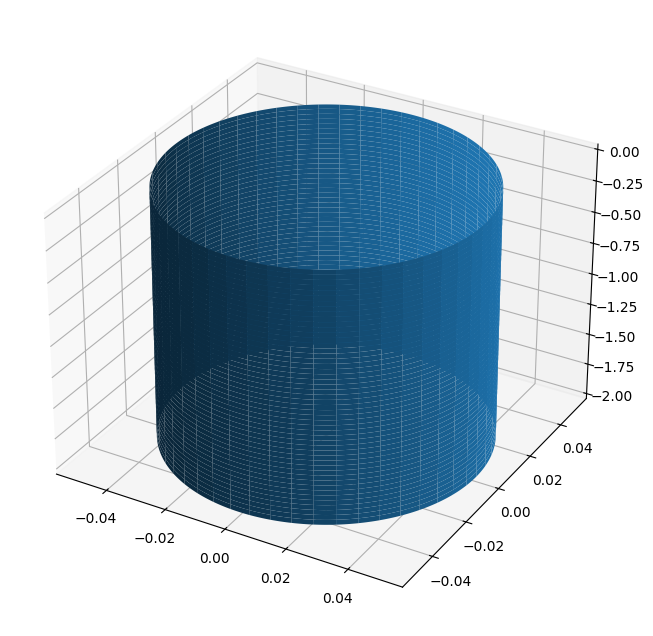

In [15]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_stem, Y_stem, Z_stem, antialiased=True, linewidth=0)

plt.show()

# 6. Putting it all Together to Create a Visual Rose with Stem

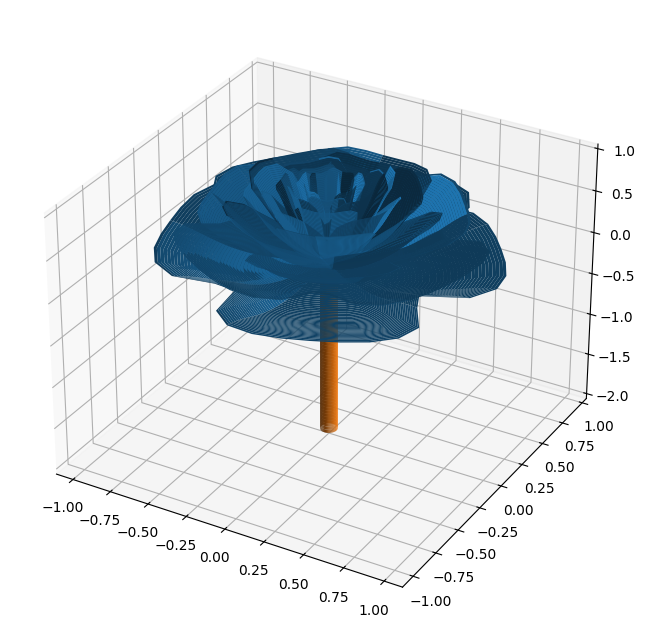

In [16]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_rose, Y_rose, Z_rose, antialiased=True, linewidth=0)
ax.plot_surface(X_stem, Y_stem, Z_stem, antialiased=True, linewidth=0)

plt.show()

# 7. Coloring with Custom Colormaps

Concepts introduced
* Color gradients
* Visual depth
* Colormap design

In [17]:
red_grad_map = LinearSegmentedColormap.from_list(
    'rose_red', [(1, 0.4, 0.4), (0.2, 0.1, 0.1)], N=100
)

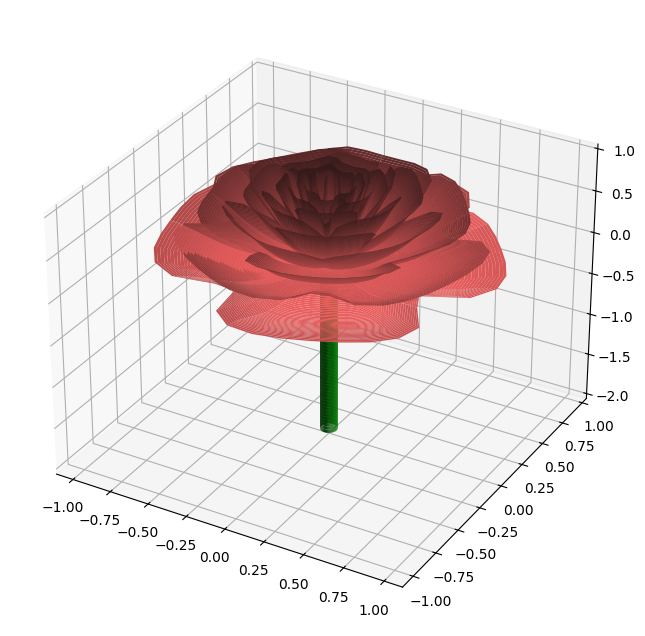

In [18]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_rose, Y_rose, Z_rose, cmap=red_grad_map, antialiased=True, linewidth=0)
ax.plot_surface(X_stem, Y_stem, Z_stem, color='green', antialiased=True, linewidth=0)

plt.show()

# 8. Assembling a Bouquet

Concepts introduced
* Translation
* Scene composition
* Reuse of geometry

In [19]:
# Inroduce new color
soft_red_map = LinearSegmentedColormap.from_list(
    'rose_soft', [(1, 0.8, 0.8), (0.5, 0.1, 0.1)], N=100
)

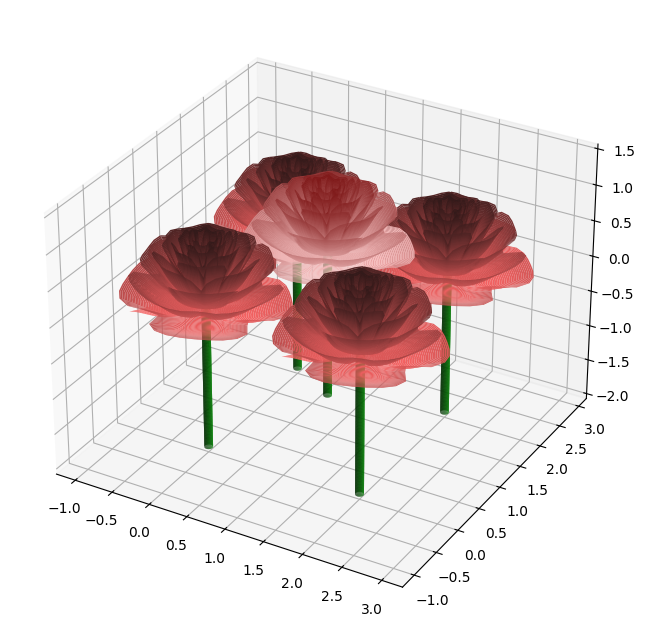

In [20]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_rose, Y_rose, Z_rose, cmap=red_grad_map, antialiased=True, linewidth=0)
ax.plot_surface(X_stem, Y_stem, Z_stem, color='green', antialiased=True, linewidth=0)

ax.plot_surface(X_rose+2, Y_rose, Z_rose, cmap=red_grad_map, antialiased=True, linewidth=0)
ax.plot_surface(X_stem+2, Y_stem, Z_stem, color='green', antialiased=True, linewidth=0)

ax.plot_surface(X_rose, Y_rose+2, Z_rose, cmap=red_grad_map, antialiased=True, linewidth=0)
ax.plot_surface(X_stem, Y_stem+2, Z_stem, color='green', antialiased=True, linewidth=0)

ax.plot_surface(X_rose+2, Y_rose+2, Z_rose, cmap=red_grad_map, antialiased=True, linewidth=0)
ax.plot_surface(X_stem+2, Y_stem+2, Z_stem, color='green', antialiased=True, linewidth=0)

ax.plot_surface(X_rose+1, Y_rose+1, Z_rose+0.5, cmap=soft_red_map, antialiased=True, linewidth=0)
ax.plot_surface(X_stem+1, Y_stem+1, Z_stem+0.5, color='green', antialiased=True, linewidth=0)

plt.show()

# 9. Create Animation: Bringing the Roses to Life

Concepts introduced
* View transforms
* Animation loops
* Efficient updates

In [23]:
def update(frame):
    offset = 0.1 * np.sin(frame / 20) # adds swaying rhythmically 
    ax.view_init(elev=30 + offset, azim=frame)
    return ax,

In [ ]:
FRAMES = 60 

angles = np.linspace(0, 360, FRAMES, endpoint=False) # endpoint=False does not repeat the first frame at the end (no duploicate angles like 0 and 360)

ani = FuncAnimation(
    fig, update,
    frames=angles,
    interval=30,
    blit=False,
    repeat=True
)


In [ ]:
# This step will take about 5min depending on your computing platform
from IPython.display import HTML
HTML(ani.to_jshtml())

In [ ]:
ani.save("roses_bouquet.gif", fps=30)

MovieWriter ffmpeg unavailable; using Pillow instead.


# 10. Animating Single Rose Blooming

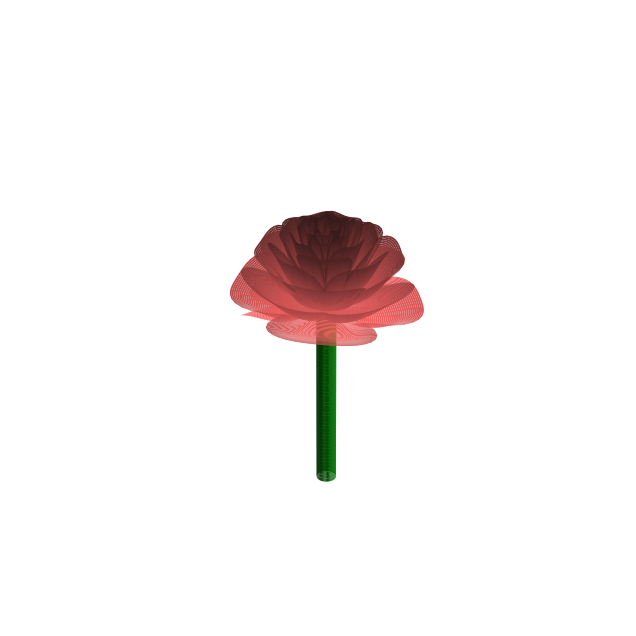

In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_rose, Y_rose, Z_rose, cmap=red_grad_map, antialiased=True, linewidth=0)
ax.plot_surface(X_stem, Y_stem, Z_stem, color='green', antialiased=True, linewidth=0)

# Set scene boundaries 
ax.set_xlim([-2, 2]) 
ax.set_ylim([-2, 2]) 
ax.set_zlim([-1.5, 1.5])

# Clean artistic look
ax.axis('off')

plt.show()

# 11. Bloom from bulb to full bloom

* frame = 0   → fully closed bulb
* frame = 100 → fully open flower

In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_stem, Y_stem, Z_stem, color='green', antialiased=True, linewidth=0)

# Set scene boundaries 
ax.set_xlim([-2, 2]) 
ax.set_ylim([-2, 2]) 
ax.set_zlim([-1.5, 1.5])

# Clean artistic look
ax.axis('off')

FRAMES = 100

# Create a placeholder for the surface
rose_plot = [None]

# Very tight bulb (strong curl) with Interpolate the entire geometry (X,Y, Z)
phi_closed = (np.pi/2) * np.exp(-(THETA + 50) / (C*np.pi))
Z_closed = 0.2 * (x*(R*np.cos(phi_closed) - y*np.sin(phi_closed))) 
X_closed = 0.15 * X_rose 
Y_closed = 0.15 * Y_rose

# Fully open flower (original phi)
phi_open = (np.pi/2) * np.exp(-(THETA) / (C*np.pi))
X_open = X_rose 
Y_open = Y_rose 
Z_open = Z_rose


def update_rose_opening(frame):
    bloom = frame / FRAMES  # 0 → 1

    # Interpolate from closed → open
    phi_dynamic = (1 - bloom) * phi_closed + bloom * phi_open
    X_dynamic = (1 - bloom) * X_closed + bloom * X_open
    Y_dynamic = (1 - bloom) * Y_closed + bloom * Y_open
    Z_dynamic = (1 - bloom) * Z_closed + bloom * Z_open

    # Radial contraction (X, Y shrink) 
    shrink = 0.15 + 0.85 * bloom # 0.15 → 1.0

    # Vertical compression (Z shrink)
    height = 0.2 + 0.8 * bloom # 0.2 → 1.0

    # Recompute dynamic coordinates
    X_dynamic = shrink * X_rose
    Y_dynamic = shrink * Y_rose
    Z_dynamic = height * (x*(R*np.cos(phi_dynamic) - y*np.sin(phi_dynamic)))

    # Remove previous surface
    if rose_plot[0] is not None:
        rose_plot[0].remove()

    # Draw new surface
    rose_plot[0] = ax.plot_surface(
        X_dynamic, Y_dynamic, Z_dynamic,
        cmap=red_grad_map,
        linewidth=0,
        antialiased=True
    )

    return rose_plot[0],

ani = FuncAnimation(
    fig,
    update_rose_opening,
    frames=FRAMES,
    interval=30,
    blit=False
)

from IPython.display import HTML
HTML(ani.to_jshtml())

In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_stem, Y_stem, Z_stem, color='green', antialiased=True, linewidth=0)

# Set scene boundaries 
ax.set_xlim([-2, 2]) 
ax.set_ylim([-2, 2]) 
ax.set_zlim([-1.5, 1.5])

# Clean artistic look
ax.axis('off')

FRAMES = 100

# Create a placeholder for the surface
rose_plot = [None]

def update_rose_opening(frame):
    bloom = (1 - np.cos(np.pi * frame / FRAMES)) / 2  # 0 → 1

    # Interpolate from closed → open
    phi_dynamic = (1 - bloom) * phi_closed + bloom * phi_open
    X_dynamic = (1 - bloom) * X_closed + bloom * X_open
    Y_dynamic = (1 - bloom) * Y_closed + bloom * Y_open
    Z_dynamic = (1 - bloom) * Z_closed + bloom * Z_open

    # Radial contraction (X, Y shrink) 
    shrink = 0.15 + 0.85 * bloom # 0.15 → 1.0

    # Vertical compression (Z shrink)
    height = 0.2 + 0.8 * bloom # 0.2 → 1.0

    # Recompute dynamic coordinates
    X_dynamic = shrink * X_rose
    Y_dynamic = shrink * Y_rose
    Z_dynamic = height * (x*(R*np.cos(phi_dynamic) - y*np.sin(phi_dynamic)))

    # Remove previous surface
    if rose_plot[0] is not None:
        rose_plot[0].remove()

    # Draw new surface
    rose_plot[0] = ax.plot_surface(
        X_dynamic, Y_dynamic, Z_dynamic,
        cmap=red_grad_map,
        linewidth=0,
        antialiased=True
    )

    return rose_plot[0],

ani = FuncAnimation(
    fig,
    update_rose_opening,
    frames=FRAMES,
    interval=30,
    blit=False
)

from IPython.display import HTML
HTML(ani.to_jshtml())

# 🌹 12. Closing Thoughts

You’ve just walked through a full creative pipeline—from simple parametric functions to a fully animated mathematical rose. Along the way, you explored how structure emerges from equations, how visualization reveals behavior, and how small changes in parameters can reshape an entire model.

This notebook is meant to be a starting point. If you’re curious, try experimenting with:

- PETAL_NUM to discover new floral patterns

- color maps and lighting for different moods

- animation timing for smoother or more dramatic motion

Python becomes more than a tool when you use it this way—it becomes a medium for exploration, design, and play.

If you want to take this further, you might:

- refactor the code into reusable functions

- turn this into a guided exercise set

- add interactive widgets

- or shape it into a short Valentine’s Day story or demo

<hr/>
Created on 2025-02-14 and Last updated on 2026-02-10 by Sumudu Tennakoon

*This project was developed from the author's original concept, with creative assistance from Microsoft Copilot, to support educational exploration and code assiatnce to create the Python code for visual ourput.*

<a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc-sa/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License</a>.